In [1]:
import numpy as np
import matplotlib.pyplot as plt
from plotsetup import *

# increase fontsizes
plt.rcParams.update({'font.size': 16})

# disable inline backend's auto-cropping so repeated redraws keep a fixed pixel size
get_ipython().run_line_magic('config', "InlineBackend.print_figure_kwargs = {'bbox_inches': None}")


In [2]:
# define a function
f = lambda x: np.exp(-x**2)
df = lambda x: -2 * x * np.exp(-x**2)

In [3]:
def zoom(magnification = 1.0, h0 = 0.01):
    x0 = 0.25
    zoom = 10**magnification
    h = h0 / zoom
    xmin = x0 - 3 / zoom
    xmax = x0 + 3 / zoom
    ymin = f(x0) - 3 / zoom
    ymax = f(x0) + 3 / zoom
    
    y0 = f(x0)
    y1 = f(x0 + h)
    slope = (y1 - y0) / h
    tangent_line = lambda x: y0 + df(x0) * (x - x0)
    approx_tangent_line = lambda x: y0 + slope * (x - x0)

    
    fig = plt.figure(figsize=(3, 3))
    x = np.linspace(xmin, xmax, 400)
    plt.plot(x, f(x))
    # mark x0 and f(x0)
    plt.scatter([x0], [f(x0)], color='red')
    # text annotation for x0 and f(x0)

    plt.text(x0+h/6, ymin + h/6, r'$x_0$')
    plt.axvline(x=x0, color='black', linestyle='--')

    plt.text(x0+h + h/6, ymin + h/6, r'$x_0 + h$')
    plt.axvline(x=x0 + h, color='black', linestyle='--')


    
    plt.scatter([x0 + h], [f(x0 + h)], color='blue')
    plt.plot(x, tangent_line(x), color='C2')
    plt.plot(x, approx_tangent_line(x), color='C1', linestyle='--')
    
    # set equal aspect ratio
    plt.xlim(xmin, xmax)
    plt.ylim(ymin, ymax)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.title(rf'$x_0 = {x0}, h = {h:.6f}$')
    plt.show()
    plt.close(fig)  # avoid accumulating figures, which was causing the layout to jump


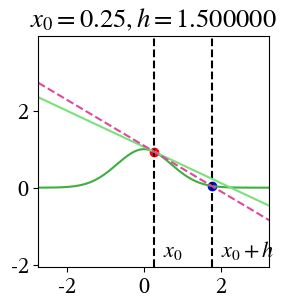

In [4]:
zoom(magnification = 0.0, h0 = 1.5)

In [5]:
from ipywidgets import FloatSlider, HBox, Output, Layout
from IPython.display import display

mag_slider = FloatSlider(description='magnification', min=0.0, max=6.0, step=0.1, value=0.0,
                          continuous_update=True, orientation='vertical',
                          layout=Layout(width='60px', height='320px'))
# fixed size prevents the surrounding page from jumping on every redraw
zoom_out = Output(layout=Layout(width='320px', height='320px'))

def update_zoom(*_):
    magnification = mag_slider.value
    if magnification is None:  # guard against transient None during widget sync
        return
    with zoom_out:
        zoom_out.clear_output(wait=True)
        zoom(magnification=magnification, h0=1.5)

mag_slider.observe(update_zoom, names='value')

display(HBox([mag_slider, zoom_out], layout=Layout(align_items='center')))

update_zoom()